# Streaming Service User Analysis

## Project Objective
The objective of this project is to analyze user behavior, preferences, and engagement with the streaming platform. The analysis focuses on subscription revenue, user engagement, demographics, retention, loyalty, and payment preferences.

### Key Analysis Areas
1. Subscription & Revenue Analysis
2. User Engagement Metrics
3. Demographic & Behavioral Insights
4. Retention & Loyalty Analysis
5. Payment Preferences & Regional Trends

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Dataset Loading

In this section, we load the streaming service dataset and examine the first few records.

In [21]:
df = pd.read_csv("streaming_service_data/streaming_service_data.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,User_ID,User_Name,Join_Date,Last_Login,Monthly_Price,Watch_Hours,Favorite_Genre,Active_Devices,Profile_Count,Parental_Controls,...,Payment_Method,Language_Preference,Recommended_Content_Count,Average_Rating_Given,Has_Downloaded_Content,Membership_Status,Loyalty_Points,First_Device_Used,Age_Group,Primary_Watch_Time
0,2518,Amber,5/15/2023,12/13/2024,7.99,49,Action,3,6,True,...,PayPal,Hindi,84,3.3,False,Active,2878,Smartphone,35-44,Late Night
1,6430,Patrick,4/3/2023,12/15/2024,7.99,161,Drama,1,2,True,...,PayPal,German,69,4.0,False,Active,2291,Desktop,25-34,Evening
2,1798,Robert,8/2/2023,12/14/2024,11.99,87,Action,2,5,False,...,Debit Card,Mandarin,56,3.1,False,Active,1692,Desktop,35-44,Late Night
3,5255,Cole,1/31/2023,12/2/2024,15.99,321,Sci-Fi,1,5,False,...,Debit Card,Mandarin,47,4.6,False,Active,952,Desktop,25-34,Evening
4,2854,Jamie,6/6/2023,12/15/2024,11.99,386,Documentary,1,4,True,...,PayPal,Mandarin,39,3.7,False,Active,1823,Desktop,25-34,Late Night


# Dataset Overview

Understanding the structure of the dataset including rows, columns, and data types.

In [22]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape:
(1000, 23)

Column Names:
['User_ID', 'User_Name', 'Join_Date', 'Last_Login', 'Monthly_Price', 'Watch_Hours', 'Favorite_Genre', 'Active_Devices', 'Profile_Count', 'Parental_Controls', 'Total_Movies_Watched', 'Total_Series_Watched', 'Country', 'Payment_Method', 'Language_Preference', 'Recommended_Content_Count', 'Average_Rating_Given', 'Has_Downloaded_Content', 'Membership_Status', 'Loyalty_Points', 'First_Device_Used', 'Age_Group', 'Primary_Watch_Time']


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    1000 non-null   int64  
 1   User_Name                  1000 non-null   str    
 2   Join_Date                  1000 non-null   str    
 3   Last_Login                 1000 non-null   str    
 4   Monthly_Price              1000 non-null   float64
 5   Watch_Hours                1000 non-null   int64  
 6   Favorite_Genre             1000 non-null   str    
 7   Active_Devices             1000 non-null   int64  
 8   Profile_Count              1000 non-null   int64  
 9   Parental_Controls          1000 non-null   bool   
 10  Total_Movies_Watched       1000 non-null   int64  
 11  Total_Series_Watched       1000 non-null   int64  
 12  Country                    1000 non-null   str    
 13  Payment_Method             1000 non-null   str    
 14  Lang

In [24]:
df.describe()

,User_ID,Monthly_Price,Watch_Hours,Active_Devices,Profile_Count,Total_Movies_Watched,Total_Series_Watched,Recommended_Content_Count,Average_Rating_Given,Loyalty_Points
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,5610.52100,12.026000,254.516000,3.04600,3.460000,515.897000,99.746000,51.482000,4.01030,2444.217000
std,2566.98922,3.238702,140.667264,1.42966,1.749703,282.697585,58.452238,29.323498,0.58459,1434.619603
min,1003.00000,7.990000,10.000000,1.00000,1.000000,12.000000,1.000000,0.000000,3.00000,3.000000
25%,3587.75000,7.990000,136.000000,2.00000,2.000000,273.750000,48.750000,26.000000,3.50000,1251.500000
50%,5694.00000,11.990000,256.000000,3.00000,3.000000,510.000000,103.000000,52.500000,4.00000,2423.000000
75%,7794.25000,15.990000,373.250000,4.00000,5.000000,770.750000,150.000000,77.000000,4.50000,3660.000000
max,9996.00000,15.990000,500.000000,5.00000,6.000000,1000.000000,200.000000,100.000000,5.00000,4990.000000


# Missing Values Analysis

Checking whether the dataset contains any missing values.

In [25]:
df.isnull().sum()

User_ID                      0
User_Name                    0
Join_Date                    0
Last_Login                   0
Monthly_Price                0
Watch_Hours                  0
Favorite_Genre               0
Active_Devices               0
Profile_Count                0
Parental_Controls            0
Total_Movies_Watched         0
Total_Series_Watched         0
Country                      0
Payment_Method               0
Language_Preference          0
Recommended_Content_Count    0
Average_Rating_Given         0
Has_Downloaded_Content       0
Membership_Status            0
Loyalty_Points               0
First_Device_Used            0
Age_Group                    0
Primary_Watch_Time           0
dtype: int64

# Subscription & Revenue Analysis

This analysis evaluates monthly subscription revenue and the distribution of users across different pricing plans.

In [26]:
total_revenue = df["Monthly_Price"].sum()

print("Total Monthly Revenue:", total_revenue)

Total Monthly Revenue: 12026.000000000002


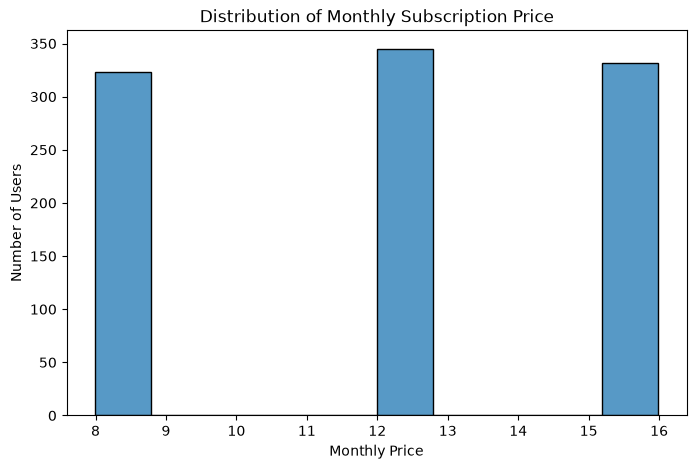

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Monthly_Price"], bins=10)

plt.title("Distribution of Monthly Subscription Price")
plt.xlabel("Monthly Price")
plt.ylabel("Number of Users")
plt.show()

# User Engagement Metrics

Analyzing watch hours and content consumption patterns.

In [28]:
average_watch_hours = df["Watch_Hours"].mean()

print("Average Watch Hours:", average_watch_hours)

Average Watch Hours: 254.516


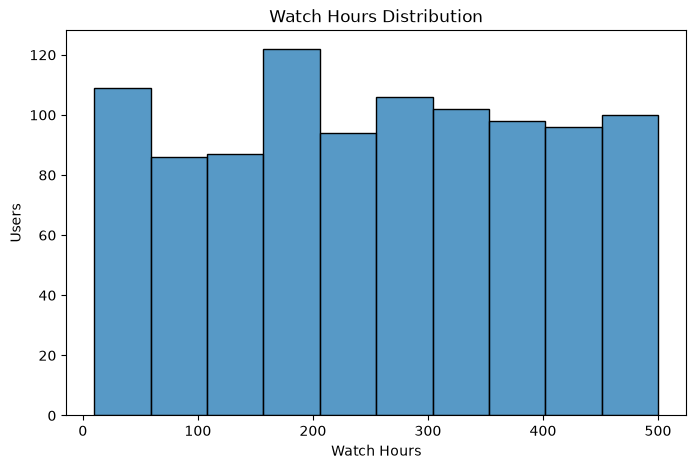

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["Watch_Hours"], bins=10)

plt.title("Watch Hours Distribution")
plt.xlabel("Watch Hours")
plt.ylabel("Users")
plt.show()

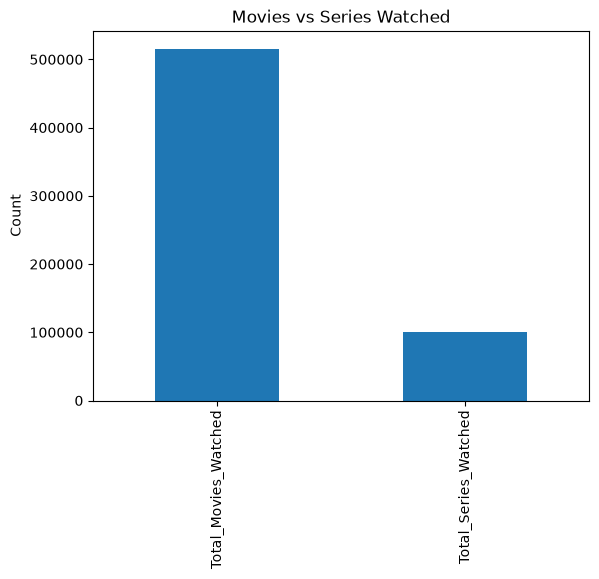

In [30]:
movies_series = df[["Total_Movies_Watched","Total_Series_Watched"]].sum()

movies_series.plot(kind="bar")

plt.title("Movies vs Series Watched")
plt.ylabel("Count")
plt.show()

# Demographic & Behavioral Insights

Analyzing age groups, favorite genres, and viewing patterns.

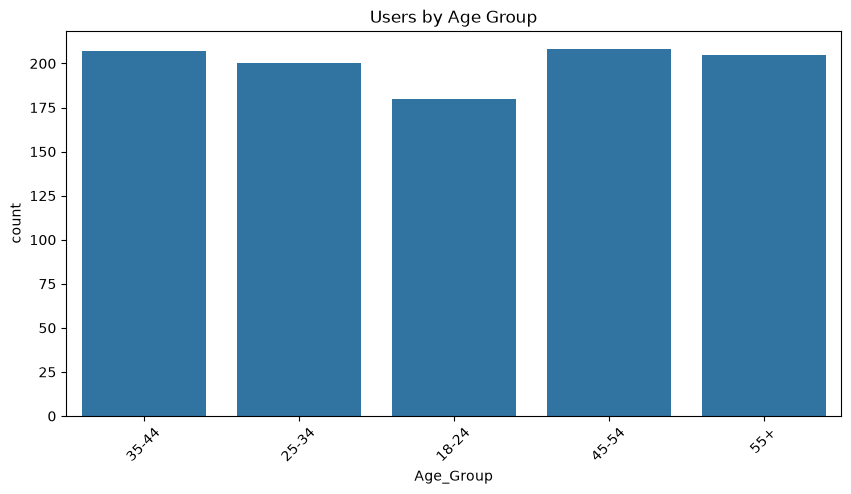

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(x="Age_Group", data=df)

plt.title("Users by Age Group")
plt.xticks(rotation=45)
plt.show()

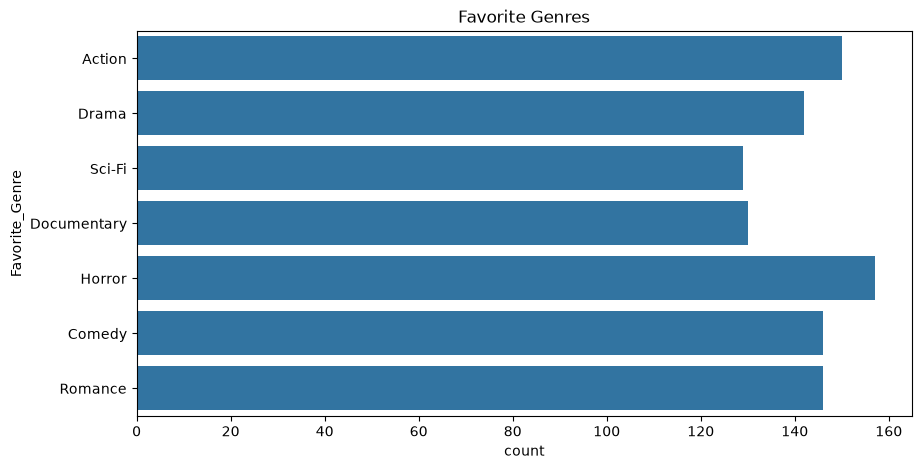

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(y="Favorite_Genre", data=df)

plt.title("Favorite Genres")
plt.show()

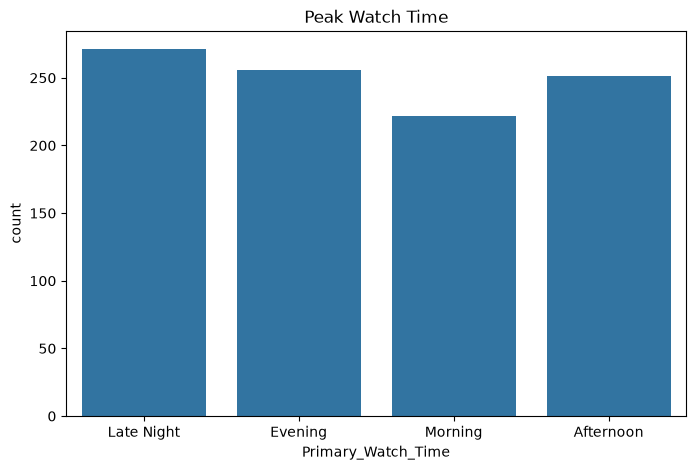

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="Primary_Watch_Time", data=df)

plt.title("Peak Watch Time")
plt.show()

# Retention & Loyalty Analysis

Evaluating membership status and loyalty point distribution.

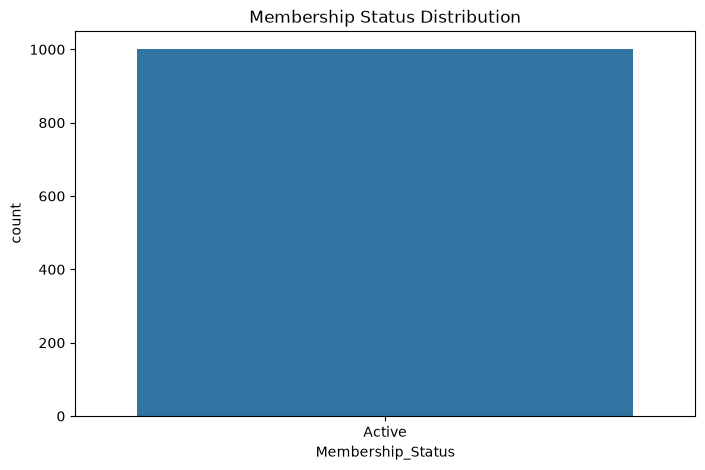

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="Membership_Status", data=df)

plt.title("Membership Status Distribution")
plt.show()

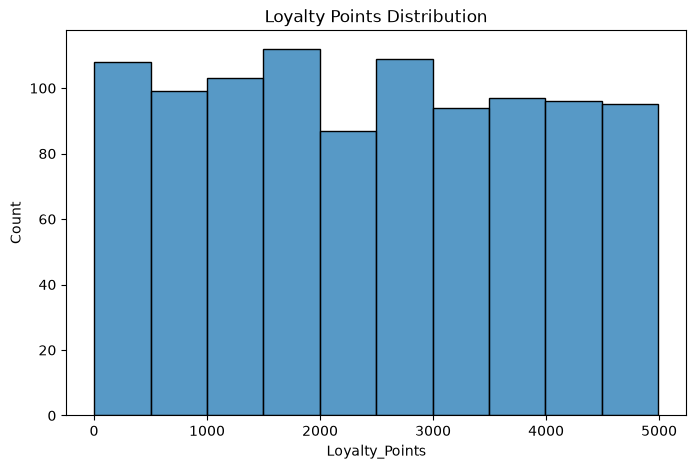

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Loyalty_Points"], bins=10)

plt.title("Loyalty Points Distribution")
plt.show()

# Payment Preferences & Regional Trends

Analyzing payment methods, countries, and language preferences.

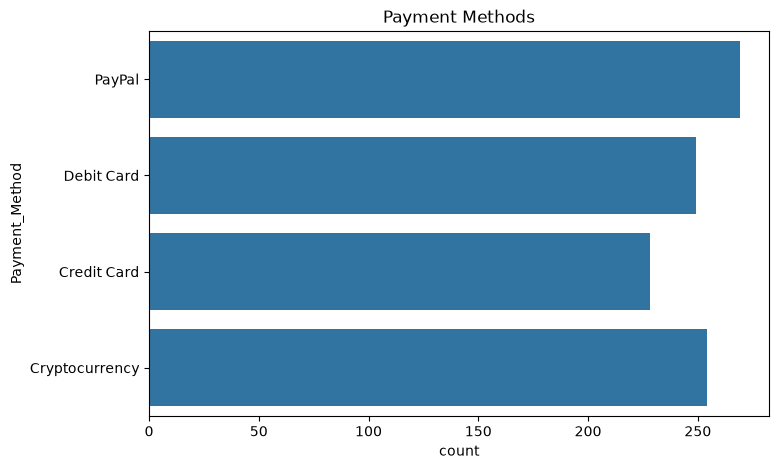

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(y="Payment_Method", data=df)

plt.title("Payment Methods")
plt.show()

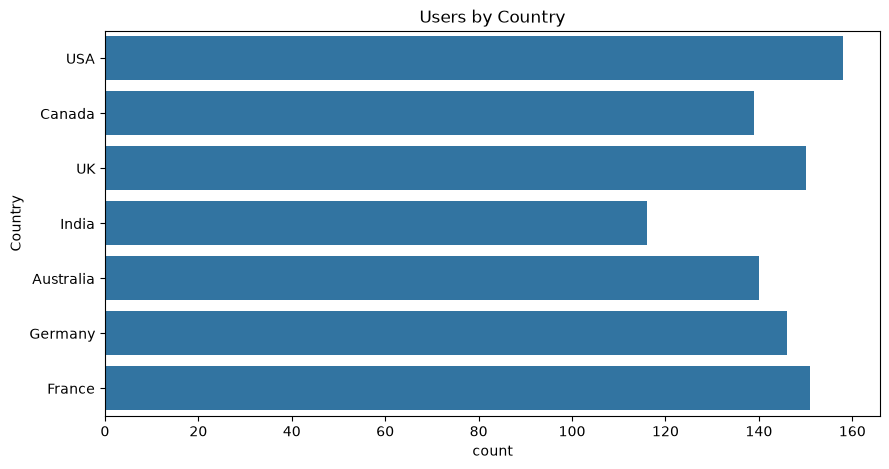

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(y="Country", data=df)

plt.title("Users by Country")
plt.show()

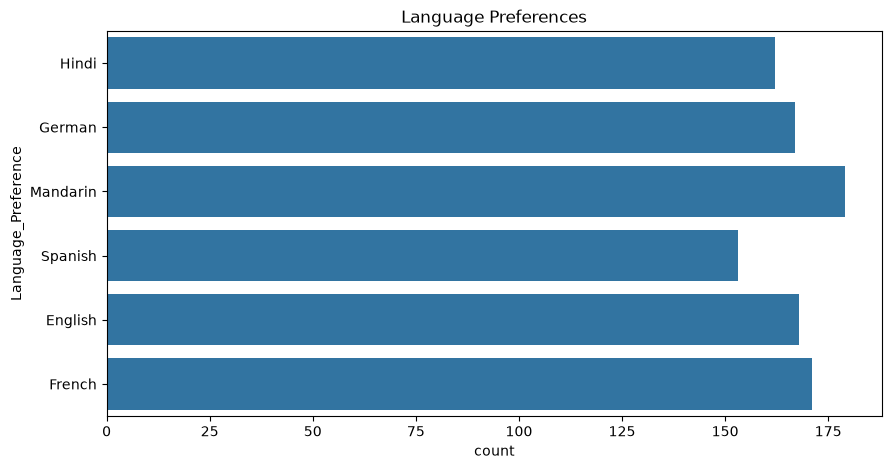

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(y="Language_Preference", data=df)

plt.title("Language Preferences")
plt.show()

# Conclusion

### Key Findings

- Revenue is generated through monthly subscription plans.
- User engagement is measured using watch hours and content consumption.
- Certain age groups prefer specific genres.
- Membership status indicates retention levels.
- Loyalty points provide insights into customer engagement.
- Payment methods and regional preferences vary across countries.

This analysis can help improve customer retention, content recommendations, and business decision-making.

# Recommended Content Impact Analysis

This analysis examines whether recommended content contributes to higher watch hours and user engagement.

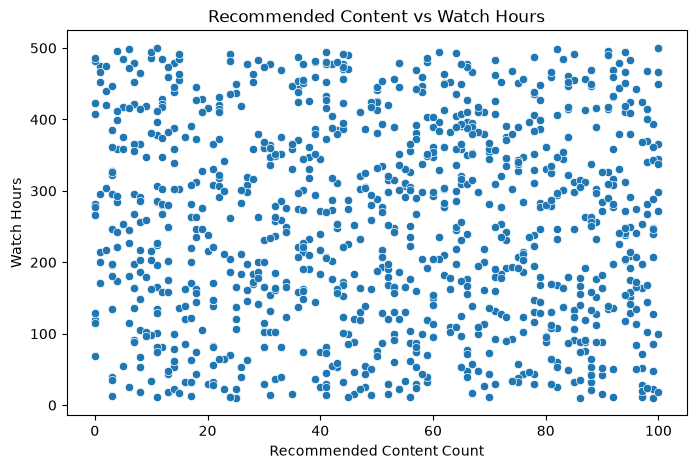

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Recommended_Content_Count',
    y='Watch_Hours',
    data=df
)

plt.title("Recommended Content vs Watch Hours")
plt.xlabel("Recommended Content Count")
plt.ylabel("Watch Hours")

plt.show()

# Correlation Analysis

Understanding relationships between numerical variables.

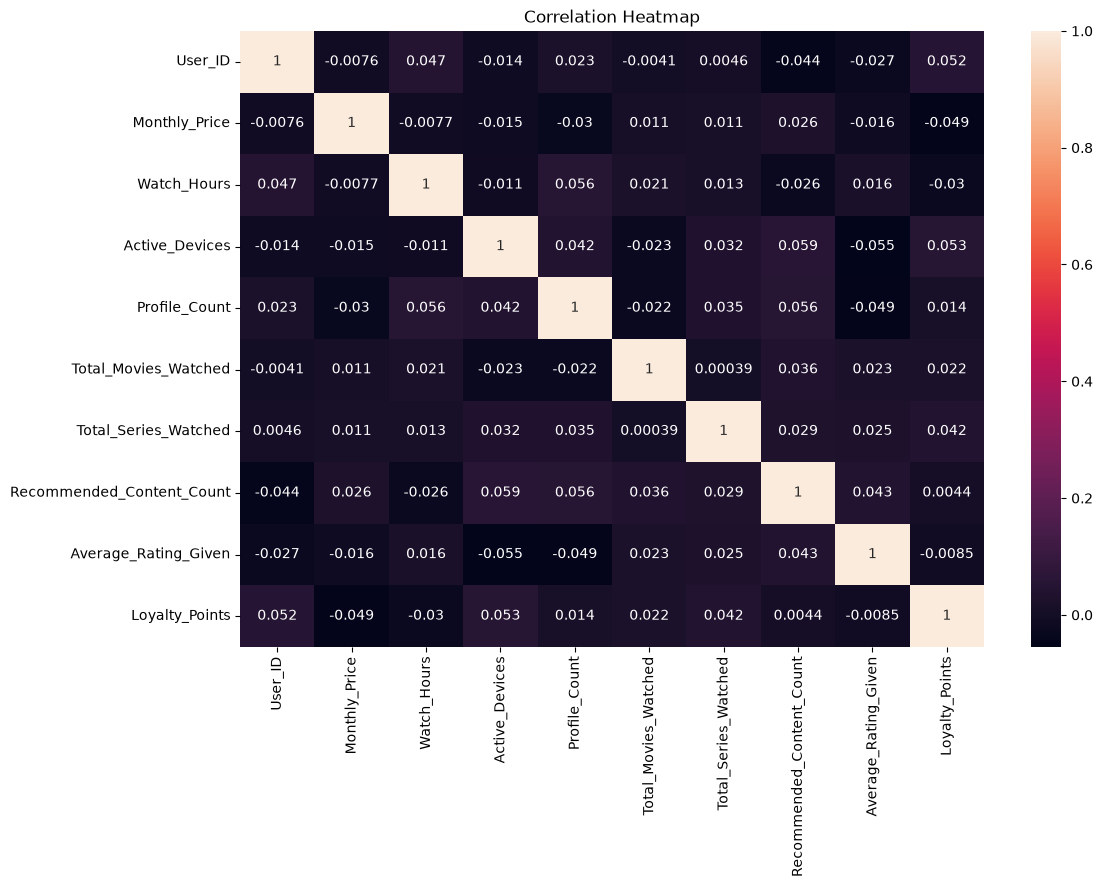

In [42]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [43]:
df.to_excel("Streaming_Service_Analysis.xlsx", index=False)

print("Excel file created successfully!")

Excel file created successfully!


In [44]:
summary = df.describe()

summary.to_excel("Summary_Statistics.xlsx")

print("Summary statistics file created!")

Summary statistics file created!


# Final Conclusion

## Project Summary

This project analyzed a streaming service dataset containing user demographics, subscription details, viewing behavior, engagement metrics, and customer preferences.

The analysis included:

- Data loading and preprocessing
- Data exploration and summary statistics
- Missing value verification
- Correlation analysis
- Visualization of user behavior and subscription trends
- Exporting results to Excel files

## Key Findings

1. Monthly subscription plans are the primary source of revenue.

2. Watch hours are an important indicator of user engagement.

3. Different users show varying content preferences based on genres.

4. Membership status and loyalty points provide insights into customer retention.

5. Content consumption patterns help understand customer behavior.

6. Correlation analysis shows relationships between engagement metrics and user activity.

## Business Insights

- Improve personalized recommendations based on viewing history.
- Focus marketing efforts on highly engaged users.
- Enhance customer retention programs using loyalty points.
- Optimize content offerings according to user preferences.
- Use engagement metrics to identify potential churn risks.

## Deliverables Generated

- Streaming_Service_Analysis.xlsx
- Summary_Statistics.xlsx
- Visualizations and statistical summaries

## Conclusion

The analysis provides valuable insights into customer behavior, engagement patterns, and subscription trends. These findings can support data-driven business decisions and improve overall user experience on the streaming platform.